# Scree plot

The scree plot draws one bar per component, with a line riding their tops. The fall from the first component to the last is what we read: where it flattens is the elbow, and the components before it are the ones worth keeping.

    plot_scree(values; ncomp = 0, compnames = ..., cumulative = false, kwargs...)

It takes a plain vector of one value per component, so it is not tied to any model. Each model passes whatever field measures the strength of its components:

| Model | Call |
|---|---|
| `pca` | `plot_scree(m.variances)` |
| `spc` | `plot_scree(m.variances)` |
| `pmd` | `plot_scree(m.d)` |
| `cca` | `plot_scree(m.corrs)` |
| `scca` | `plot_scree(m.cors)` |
| `jive` | `plot_scree(vcat(m.r, m.ri))` |

The regression and discriminant models — `plskern`, `plsda`, `splsda` — store no per-component strength, so they have no scree to draw.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs

## A simulated example

The same data as the other notebooks: three latent signals driving twenty variables. Because only three signals are at work, we expect the scree to fall sharply after the third component — that fall is exactly what the plot is for.

In [2]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

m = pca(X; k = 8)

round.(m.variances, digits = 3)

8-element Vector{Float64}:
 37.563
 24.911
 18.13
  0.166
  0.154
  0.134
  0.117
  0.114

## The default plot

Given the variances, we get a bar per component with the line on top and the components ticked by index. The elbow after the third component should be plain.

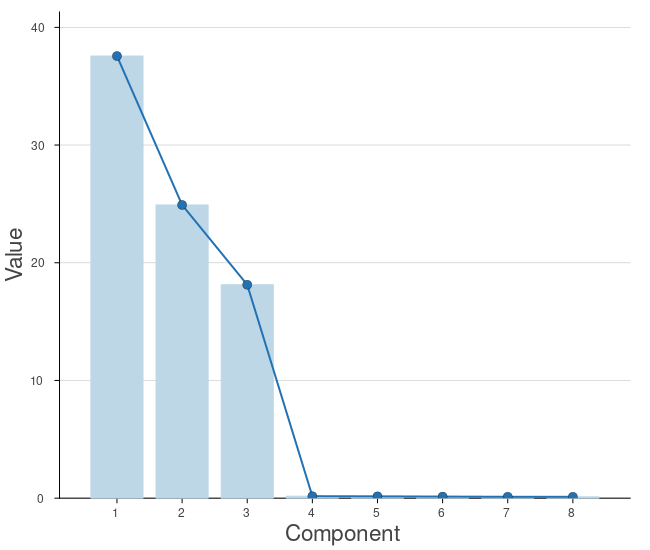

In [3]:
plot_scree(m.variances)

---

# Modifying the plot

There are two things to decide, and they are independent.

The first is **what quantity we pass**, which the plot never chooses for us:

- `m.variances` — the raw variance of each component, which falls off
- `m.propOFvar` — the same shape scaled to sum to one, so we can say "PC1 explains 55%"

The second is **whether it is summed**, which is what `cumulative` controls. Passing `propOFvar` with `cumulative = true` gives the rising curve we read against a threshold.

On top of that, `ncomp` truncates the tail, `compnames` names the components, and `showline` removes the line.

## Naming and truncating

`compnames` names the components — passed as an argument rather than as `xticks`, because the names are subset along with the values, so a truncated plot keeps the right labels. `ncomp` keeps only the leading components, dropping a long flat tail that tells us nothing.

Here we also switch from raw variance to the proportion, which makes the y axis directly interpretable.

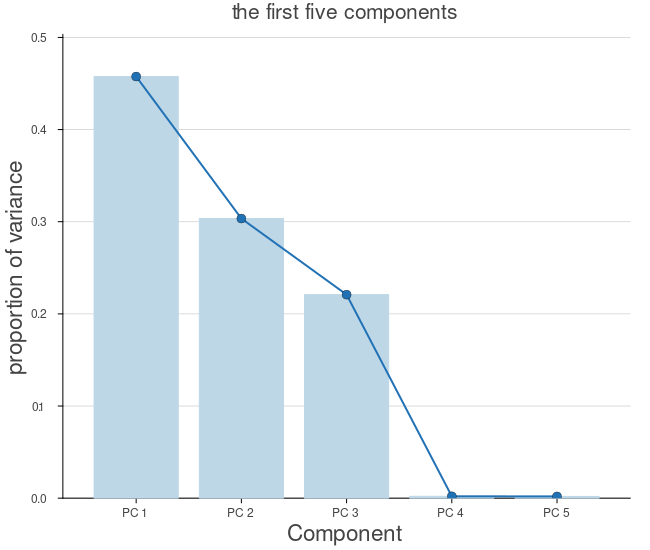

In [4]:
plot_scree(m.propOFvar;
           compnames = ["PC $(j)" for j in 1:8],
           ncomp     = 5,
           ylabel    = "proportion of variance",
           title     = "the first five components")

## The cumulative view

With `cumulative = true` the running total is drawn instead of the per-component value. Read against the proportion of variance it answers the practical question directly: how many components do we need to reach 90 percent?

We drop the line here with `showline = false`. On a cumulative curve the bars rise to a plateau near one and the line rides that plateau, which reads oddly — bars alone are cleaner. We also draw a threshold across the plot to read against.

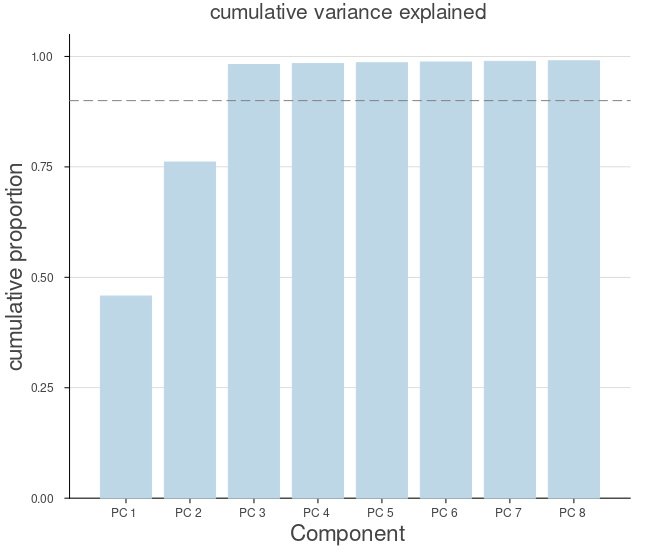

In [5]:
plot_scree(m.propOFvar;
           compnames  = ["PC $(j)" for j in 1:8],
           cumulative = true,
           showline   = false,
           ylabel     = "cumulative proportion",
           title      = "cumulative variance explained",
           ylims      = (0, 1.05))

hline!([0.9]; linestyle = :dash, color = :grey, label = "90%")

## Colors and the rest

Two color knobs of our own: `barcolor` for the bars and `linecolor_` for the line on top. The trailing underscore is deliberate — `linecolor` is a standard `Plots` attribute, so the bare name would be intercepted before it reached us.

Everything else the plot sets for itself yields to what we pass, so the usual attributes stack on top.

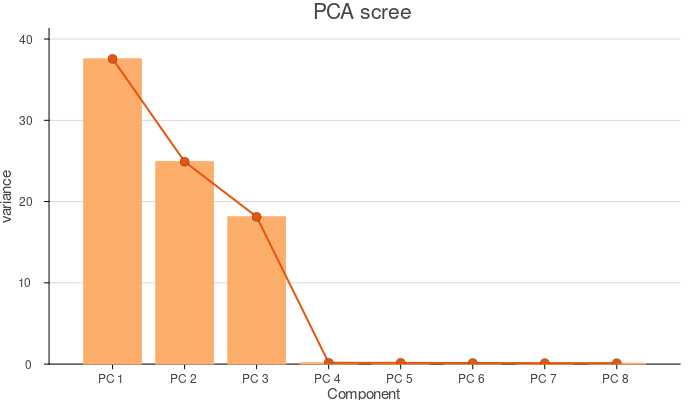

In [6]:
plot_scree(m.variances;
           compnames     = ["PC $(j)" for j in 1:8],
           barcolor      = "#fdae6b",
           linecolor_    = "#e6550d",
           ylabel        = "variance",
           title         = "PCA scree",
           size          = (700, 400),
           guidefontsize = 10)